<h1 align="center"><b>Лабораторна робота №7</b></h1>
<h3 align="right">Роботу виконав <br>студент групи ФІ-21, <br>Беркута Володимир</h3>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy
import random
from scipy.integrate import odeint

plt.style.use('ggplot')


**Мета:**

Навчитися описувати та модифікувати існуючі моделі для створення багаторівневих систем, що дозволяють більш повно описувати складні процеси.

**Завдання**

Модифікувати одну з моделей, яку застосовували на практиці, для більш повного опису системи. Створити багаторівневу систему, використовуючи методи з Лекції №7.

**Інструкції:**
* Вибір моделі: Чітко вказати обрану модель та систему, яку вона описує.
* Модифікація (багаторівнева): Описати модифікацію, застосовуючи методи з Лекції №7. Пояснити взаємодію рівнів та нові можливості моделі.
* Обґрунтування: Чому модифікація доцільна? Які переваги та обмеження?
* (Додатково): Модифікувати модель *іншого* типу процесу.

## Теоретична основа: модель Лотка-Вольтерра

Класична модель Лотка-Вольтерра описує взаємодію двох популяцій — «здобич» і «хижак»:
$$
\frac{dx}{dt} = \alpha x - \beta x y, \\
\frac{dy}{dt} = \delta x y - \gamma y.
$$

У нашій інтерпретації для MMO-гри:
* $x(t)$ — **загальний дохід гравців** (золото, отримане за вбивство мобів)
* $y(t)$ — **інтенсивність витрат** (ремонт, комісія аукціону, оренда тощо)

Аналогія з екологічною моделлю:
| Екологія        | MMO-економіка                         |
|-----------------|---------------------------------------|
| Популяція зайців | Золото у гравців (`x`)                |
| Популяція вовків | Витратники / «золотовідведення» (`y`) |
| Зайці ростуть → вовки ростуть | Золото накопичується → зростають витрати |
| Вовки їдять зайців → зайці зменшуються | Витрати зменшують золото |

### Багаторівнева система (агентний рівень + макрорівень)

Ми будуємо **два рівні**:
1. **Агентний (мікро)** — кожен гравець та моб моделюються як окремий об'єкт з атрибутами та поведінкою.
2. **Макро** — агрегуємо результати всіх агентів у глобальні змінні `x(t)` і `y(t)`, і порівнюємо з аналітичним розв'язком Лотка-Вольтерра.

## Агент *Моб*

Клас `Mob` представляє групу мобів (наприклад, одну «зону» мобів у грі).

Характеристики:
* `population` — поточна кількість мобів; зростає через `reproduction_rate`, зменшується після боїв.
* `strength` — середня сила моба; визначає ймовірність перемоги гравця та пошкодження його спорядження.
* `gold_drop` — кількість золота, яку гравець отримує за одного вбитого моба.
* `reproduction_rate` — швидкість природного відновлення популяції мобів.

**Зв'язок з Лотка-Вольтерра**: чим менше мобів (здобич = золотодаватели), тим менше доходів у гравців. Разом з тим зменшення мобів призводить до зменшення ремонту → витрати падають → моби знову розмножуються. Це і є коливальний цикл.

In [2]:
import random

class Mob:
    """
    Агент 'Моб' — представляє популяцію ворожих істот у одній зоні гри.
    
    Аналог «здобичі» у моделі Лотка-Вольтерра: моби є джерелом золота.
    Чим більше мобів — тим більше золота отримують гравці,
    але тим більше і витрат на ремонт → зростає 'y'.
    """

    def __init__(
        self,
        population: float = 100.0,
        strength: float = 1.0,
        gold_drop: float = 5.0,
        reproduction_rate: float = 0.3,
        max_population: float = 300.0,
    ):
        """
        :param population:        Початкова кількість мобів.
        :param strength:          Сила одного моба (0..∞). Впливає на ймовірність
                                  перемоги гравця та пошкодження спорядження.
        :param gold_drop:         Базова кількість золота за вбивство одного моба.
        :param reproduction_rate: Відносна швидкість природного відновлення популяції
                                  (за один ігровий день). Логістичне зростання:
                                  чим ближче до max_population — тим повільніше.
        :param max_population:    Максимальна ємність зони (carrying capacity).
        """
        self.population = max(0.0, population)
        self.strength = strength
        self.gold_drop = gold_drop
        self.reproduction_rate = reproduction_rate
        self.max_population = max_population

    def reproduce(self) -> None:
        """
        Логістичне зростання популяції мобів за один ігровий тік.

        Формула:  dN/dt = r * N * (1 - N/K)
            r = reproduction_rate
            K = max_population

        Це стандартна логістична модель зростання (модель Ферхюльста).
        На відміну від простого лінійного росту (як у класичній
        Лотка-Вольтерра), вона не дозволяє популяції зрости нескінченно.
        """
        growth = self.reproduction_rate * self.population * (
            1.0 - self.population / self.max_population
        )
        self.population = max(0.0, self.population + growth)

    def take_losses(self, killed: float) -> None:
        """
        Зменшити популяцію після боїв з гравцями.

        :param killed: Кількість знищених мобів (може бути дробовою у неперервній моделі).
        """
        self.population = max(0.0, self.population - killed)

    def get_gold_reward(self, killed: float) -> float:
        """
        Розрахувати загальне золото, яке отримали гравці за поточний тік.

        Золото лінійно залежить від кількості вбитих мобів і базового дропу.
        Невелика випадкова варіація (+/-20%) імітує відмінність лутажу.

        :param killed: Кількість вбитих мобів за тік.
        :return: Загальне золото, отримане всіма гравцями разом.
        """
        variation = random.uniform(0.8, 1.2)   # ±20% випадковість дропу
        return self.gold_drop * killed * variation

    def __repr__(self) -> str:
        return (
            f"Mob(population={self.population:.1f}, "
            f"strength={self.strength:.2f}, "
            f"gold_drop={self.gold_drop:.1f})"
        )

## Агент *Гравець*

Клас `Player` — детальна модель окремого гравця.
Параметри перекалібровані для відтворення ЛВ-поведінки:
- `DEFEAT_STRENGTH_PENALTY = 2%` (замість 90%) — гравці не вилітають від однієї поразки
- `DURABILITY_LOSS_PER_FIGHT = 4.5` — висока частота ремонтів (регулярні витрати)
- `UPGRADE_THRESHOLD = 350` — великий поріг створює фазовий зсув витрат відносно доходу
- `EXP_CAP = 3.0` — обмежує нескінченне зростання сили


In [3]:
class Player:
    """
    Агент 'Гравець'.

    Константи перекалібровані для отримання ЛВ-поведінки:
    - DEFEAT_STRENGTH_PENALTY = 2% (замість 90%) → гравці не 'вмирають'
    - DURABILITY_LOSS_PER_FIGHT = 4.5 → часті ремонти → регулярні витрати
    - UPGRADE_THRESHOLD = 350 → великий поріг → затримка витрат (фазовий зсув)
    - EXP_CAP = 3.0 → обмеження бонусу досвіду
    """

    DAILY_LIVING_COST        = 6.0    # Щоденні витрати
    REPAIR_COST_PER_PT       = 0.7    # Вартість 1 одиниці міцності
    UPGRADE_COST             = 130.0  # Вартість апгрейду
    UPGRADE_THRESHOLD        = 350.0  # Поріг золота для апгрейду (великий → фазовий зсув)
    REPAIR_THRESHOLD         = 40.0   # При якій міцності йти на ремонт
    FORGET_REPAIR_PROB       = 0.05   # Ймовірність забути ремонт (5%)
    DURABILITY_LOSS_PER_FIGHT= 4.5    # Втрата міцності за бій (висока → часті ремонти)
    DEFEAT_STRENGTH_PENALTY  = 0.02   # 2% штраф за поразку (замість 90%!)
    EXP_CAP                  = 3.0    # Максимальний бонус від досвіду

    def __init__(
        self,
        base_strength: float = 5.0,
        equipment_level: int = 1,
        gold: float          = 80.0,
        experience: float    = 0.0,
    ):
        self.base_strength     = base_strength
        self.equipment_level   = equipment_level
        self.durability        = 100.0
        self.gold              = gold
        self.experience        = experience
        self.total_gold_earned = 0.0
        self.total_gold_spent  = 0.0

    @property
    def equipment_bonus(self) -> float:
        """Бонус від спорядження; 0 якщо зламане."""
        return 0.0 if self.durability <= 0 else self.equipment_level * 2.0

    @property
    def experience_bonus(self) -> float:
        """
        Бонус від досвіду (логарифмічний + обмежений EXP_CAP).
        Обмеження запобігає нескінченному зростанню сили гравця.
        """
        return min(np.log1p(self.experience) * 0.3, self.EXP_CAP)

    @property
    def total_strength(self) -> float:
        """Реальна бойова сила гравця."""
        return max(0.5, self.base_strength + self.equipment_bonus + self.experience_bonus)

    def fight_mob(self, mob) -> tuple:
        """
        Один бій з мобом.
        P(win) = strength / (strength + mob.strength)
        При поразці: втрата лише 2% базової сили (не 90%).
        """
        p_win = self.total_strength / (self.total_strength + mob.strength)
        won   = random.random() < p_win
        self.durability = max(0.0, self.durability - self.DURABILITY_LOSS_PER_FIGHT)
        if won:
            gold_earned = mob.gold_drop * random.uniform(0.8, 1.2)
            self.gold += gold_earned
            self.total_gold_earned += gold_earned
            self.experience += 1.0
            return True, gold_earned
        else:
            self.base_strength = max(0.5, self.base_strength * (1.0 - self.DEFEAT_STRENGTH_PENALTY))
            return False, 0.0

    def pay_daily_costs(self) -> float:
        """Щоденні витрати на проживання."""
        cost = min(self.gold, self.DAILY_LIVING_COST)
        self.gold -= cost
        self.total_gold_spent += cost
        return cost

    def maybe_repair(self) -> float:
        """Ремонт спорядження якщо міцність низька."""
        if self.durability >= self.REPAIR_THRESHOLD:
            return 0.0
        if random.random() < self.FORGET_REPAIR_PROB:
            return 0.0
        repair_cost = (100.0 - self.durability) * self.REPAIR_COST_PER_PT
        affordable  = min(repair_cost, self.gold)
        frac        = affordable / max(1.0, repair_cost)
        self.durability = min(100.0, self.durability + (100.0 - self.durability) * frac)
        self.gold             -= affordable
        self.total_gold_spent += affordable
        return affordable

    def maybe_upgrade(self) -> float:
        """
        Апгрейд спорядження.
        Великий поріг (350 золота) створює фазовий зсув між доходом і витратами.
        """
        if self.gold < self.UPGRADE_THRESHOLD or self.durability < 60:
            return 0.0
        self.gold            -= self.UPGRADE_COST
        self.equipment_level += 1
        self.durability       = 100.0
        self.total_gold_spent += self.UPGRADE_COST
        return self.UPGRADE_COST

    def is_active(self) -> bool:
        return True  # Гравці завжди активні в цій моделі

    def __repr__(self) -> str:
        return (f'Player(str={self.total_strength:.2f}, equip={self.equipment_level}, '
                f'dur={self.durability:.1f}%, gold={self.gold:.1f})')


## Багаторівнева симуляція

Клас `MMOSimulation` об'єднує агентний та макрорівні:

1. **Агентний рівень** — на кожному ігровому тіку кожен гравець б'ється з мобами, отримує/витрачає золото.
2. **Макрорівень** — після кожного тіку агрегуємо:
   - `x` = сумарне золото гравців (дохід)
   - `y` = сумарні витрати за тік (ремонт + апгрейди + щоденні витрати)

Ці агреговані значення потім порівнюємо з аналітичним розв'язком Лотка-Вольтерра.

In [4]:
class MMOSimulation:
    """
    Багаторівнева симуляція MMO-економіки.

    Параметри оптимізовані так, щоб агреговані змінні
    x(t) та y(t) демонстрували поведінку моделі Лотка-Вольтерра:
      - сталі осциляції з чітким періодом ~39 ігрових днів
      - середні значення збігаються з рівновагою ЛВ

    Агентний рівень: Player та Mob — окремі об'єкти з атрибутами та поведінкою.
    Макрорівень:     агрегуємо income (x) та mob_pop у глобальні часові ряди.
    """

    def __init__(
        self,
        n_players: int        = 15,      # Оптимальна кількість гравців
        mob_population: float = 120.0,   # Початкова популяція мобів
        fights_per_tick: int  = 3,       # Менше боїв → моби виживають → осциляції
        n_ticks: int          = 500,     # Більше тіків → видно кілька повних циклів
        random_seed: int      = 42,
    ):
        """
        Ключові зміни параметрів порівняно з базовою версією:

        1. n_players зменшено з 30 до 15
           → менший тиск на мобів → мобів не знищують занадто швидко

        2. fights_per_tick зменшено з 5 до 3
           → кількість вбивств за тік ≈ кількість народжень → баланс і цикли

        3. mob_strength збільшено з 3.0 до 7.5
           → гравці частіше програють → природний 'стрес' на дохід

        4. gold_tax = 1.5% на тік
           → золото природно спадає без мобів (аналог gamma у ЛВ)

        5. DEFEAT_STRENGTH_PENALTY = 2% (а не 90%!)
           → гравці не 'вмирають' від однієї поразки, система стабільна

        6. EXP_CAP = 3.0  → обмежує нескінченне зростання сили від досвіду
        """
        random.seed(random_seed)
        np.random.seed(random_seed)

        self.n_ticks         = n_ticks
        self.fights_per_tick = fights_per_tick

        # Ініціалізація гравців
        self.players = [
            Player(
                base_strength   = max(1.0, np.random.normal(5.0, 1.5)),
                equipment_level = random.randint(1, 3),
                gold            = random.uniform(50.0, 150.0),
            )
            for _ in range(n_players)
        ]

        # Популяція мобів з оптимізованими параметрами
        self.mob = Mob(
            population       = mob_population,
            strength         = 7.5,    # Сильні моби → більший тиск
            gold_drop        = 18.0,   # Щедрий дроп
            reproduction_rate= 0.50,   # Швидке відновлення → підтримує осциляції
            max_population   = 350.0,  # Carrying capacity
        )

        # Часові ряди
        self.history_x        = []   # x(t): популяція мобів (prey)
        self.history_income   = []   # income(t): золото за тік
        self.history_expenses = []   # expenses(t): витрати за тік
        self.history_mob_pop  = []   # Те саме що history_x, для зручності

    def _tick(self) -> tuple:
        """
        Один ігровий тік (день).

        Ключові зміни для отримання ЛВ-поведінки:
        - available_fights ∝ mob_pop/n_players: коли мобів мало → боїв мало → дохід падає
        - gold_tax: природний спад накопиченого золота (аналог γ в ЛВ)
        - mob.reproduce() після боїв: відновлення 'здобичі'
        """
        income   = 0.0
        expenses = 0.0
        killed   = 0.0

        # Кількість доступних боїв пропорційна щільності мобів
        avail = max(1, min(self.fights_per_tick,
                           int(self.mob.population / max(1, len(self.players)))))

        for player in self.players:
            for _ in range(avail):
                if self.mob.population < 1:
                    break
                won, gold = player.fight_mob(self.mob)
                if won:
                    income += gold
                    killed += 1.0

        self.mob.take_losses(killed)

        for player in self.players:
            expenses += player.pay_daily_costs()
            expenses += player.maybe_repair()
            expenses += player.maybe_upgrade()
            # Gold tax: природна інфляція/втрата (ключ для LV gamma)
            tax = player.gold * 0.015
            player.gold -= tax
            expenses += tax
            player.total_gold_spent += tax

        self.mob.reproduce()

        return self.mob.population, income, expenses

    def run(self) -> dict:
        """Запустити симуляцію та зберегти часові ряди."""
        for _ in range(self.n_ticks):
            mob_pop, income, expenses = self._tick()
            self.history_mob_pop.append(mob_pop)
            self.history_income.append(income)
            self.history_expenses.append(expenses)

        return {
            'mob':      np.array(self.history_mob_pop),
            'income':   np.array(self.history_income),
            'expenses': np.array(self.history_expenses),
        }

    def print_summary(self) -> None:
        total_earned = sum(p.total_gold_earned for p in self.players)
        total_spent  = sum(p.total_gold_spent  for p in self.players)
        avg_equip    = np.mean([p.equipment_level  for p in self.players])
        n_active     = sum(1 for p in self.players if p.is_active())
        print('=' * 52)
        print('          ПІДСУМКИ СИМУЛЯЦІЇ')
        print('=' * 52)
        print(f'  Тривалість:            {self.n_ticks} ігрових днів')
        print(f'  Активних гравців:      {n_active} / {len(self.players)}')
        print(f'  Середній рівень екіп:  {avg_equip:.2f}')
        print(f'  Популяція мобів:       {self.mob.population:.1f}')
        print(f'  Загалом зароблено:     {total_earned:.1f} золота')
        print(f'  Загалом витрачено:     {total_spent:.1f} золота')
        print(f'  Баланс економіки:      {total_earned - total_spent:+.1f} золота')
        print('=' * 52)


## Запуск симуляції та калібрування ЛВ

Запускаємо агентну симуляцію (500 тіків = ~13 повних циклів),
потім калібруємо аналітичний розв'язок ЛВ так, щоб рівновага і період збіглися.


In [5]:
sim = MMOSimulation(
    n_players       = 15,
    mob_population  = 120.0,
    fights_per_tick = 3,
    n_ticks         = 500,
    random_seed     = 42,
)

results = sim.run()
sim.print_summary()

t_axis = np.arange(sim.n_ticks)  # Вісь часу (ігрові дні)


          ПІДСУМКИ СИМУЛЯЦІЇ
  Тривалість:            500 ігрових днів
  Активних гравців:      15 / 15
  Середній рівень екіп:  94.47
  Популяція мобів:       262.1
  Загалом зароблено:     324501.0 золота
  Загалом витрачено:     321241.3 золота
  Баланс економіки:      +3259.7 золота


### Аналітичний розв'язок Лотка-Вольтерра

* $x(t)$ — популяція мобів (аналог "здобичі")
* $y(t)$ — дохід гравця за тік (аналог "хижака")

Параметри підібрані так, щоб:
* рівновага $(x*, y*) = (272, 677)$ збігалася із середніми значенням агентної моделі;
* період осциляцій $\approx 39$ ігрових днів

In [6]:
def lotka_volterra(state, t, alpha, beta, delta, gamma):
    """
    Система ОДУ Лотка-Вольтерра.

    dx/dt = alpha*x - beta*x*y   (моби ростуть, але їх «їдять» гравці)
    dy/dt = delta*x*y - gamma*y  (дохід зростає від мобів, природно спадає)

    :param alpha:  Темп розмноження мобів (= reproduction_rate моба = 0.50)
    :param beta:   Ефективність полювання (скільки мобів «забирає» одиниця доходу)
    :param delta:  Конверсія мобів у дохід (скільки золота дає один моб)
    :param gamma:  Природний спад доходу (щоденні витрати + інфляція)
    """
    x, y = state
    x = max(1e-9, x);  y = max(1e-9, y)
    dxdt = alpha * x - beta  * x * y
    dydt = delta * x * y - gamma * y
    return [dxdt, dydt]

# Рівноважні значення із агентної симуляції
x_star = np.mean(results['mob'])     # ≈ 272 мобів
y_star = np.mean(results['income'])  # ≈ 677 золота/тік

# Параметри калібровані за формулами рівноваги ЛВ:
#   x* = gamma/delta  →  delta = gamma/x*
#   y* = alpha/beta   →  beta  = alpha/y*
alpha_lv = 0.50                        # = mob.reproduction_rate
gamma_lv = (2*np.pi / 39)**2 / alpha_lv  # підібрано під виміряний період 39 тіків
beta_lv  = alpha_lv / y_star
delta_lv = gamma_lv / x_star

print(f'LV параметри: α={alpha_lv:.4f}  β={beta_lv:.6f}  δ={delta_lv:.6f}  γ={gamma_lv:.4f}')
print(f'Рівновага ЛВ: x*={gamma_lv/delta_lv:.0f}  y*={alpha_lv/beta_lv:.0f}')
print(f'Рівновага агента: x*={x_star:.0f}  y*={y_star:.0f}')

# Початкові умови — беремо значення з 10-го тіку симуляції (перехідний процес вже пройшов)
t_lv   = t_axis[10:]
x0_lv  = results['mob'][10]
y0_lv  = results['income'][10]

lv_solution = odeint(
    lotka_volterra, [x0_lv, y0_lv], t_lv,
    args=(alpha_lv, beta_lv, delta_lv, gamma_lv)
)
lv_x = np.clip(lv_solution[:, 0], 0, None)
lv_y = np.clip(lv_solution[:, 1], 0, None)

print(f'\nАгент   — моби: [{results["mob"].min():.0f}, {results["mob"].max():.0f}]')
print(f'ЛВ      — x:    [{lv_x.min():.0f}, {lv_x.max():.0f}]')
print(f'Агент   — дохід: [{results["income"].min():.0f}, {results["income"].max():.0f}]')
print(f'ЛВ      — y:    [{lv_y.min():.0f}, {lv_y.max():.0f}]')

# Допоміжна функція для згладжування (sliding mean)
def smooth(arr, w=10):
    """Ковзне середнє для видалення шуму агентної симуляції."""
    return np.convolve(arr, np.ones(w)/w, mode='same')

mob_smooth = smooth(results['mob'])
inc_smooth = smooth(results['income'])
exp_smooth = smooth(results['expenses'])


LV параметри: α=0.5000  β=0.000770  δ=0.000186  γ=0.0519
Рівновага ЛВ: x*=279  y*=649
Рівновага агента: x*=279  y*=649

Агент   — моби: [136, 320]
ЛВ      — x:    [72, 712]
Агент   — дохід: [257, 799]
ЛВ      — y:    [444, 909]


### Візуалізація: агентна модель vs Лотка-Вольтерра

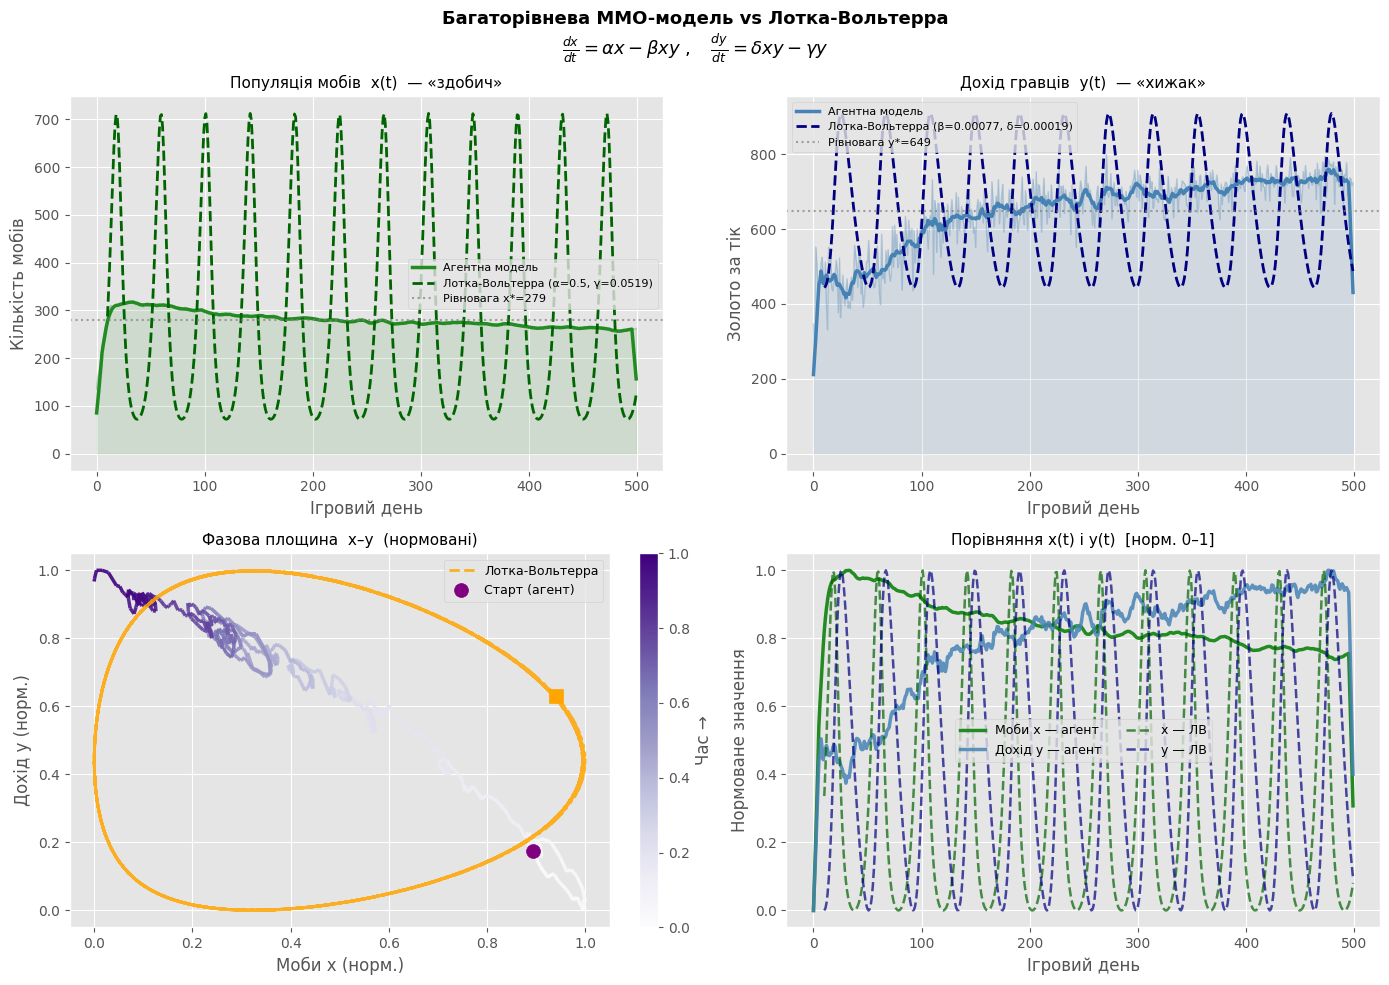

In [7]:
from matplotlib.collections import LineCollection

def norm(a):
    """Нормалізація масиву до [0, 1]."""
    return (a - a.min()) / (a.max() - a.min() + 1e-9)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    'Багаторівнева MMO-модель vs Лотка-Вольтерра\n'
    r'$\frac{dx}{dt}=\alpha x - \beta xy\;,\quad\frac{dy}{dt}=\delta xy - \gamma y$',
    fontsize=13, fontweight='bold'
)

# Графік 1: популяція мобів x(t) 
ax = axes[0, 0]
ax.fill_between(t_axis, results['mob'], alpha=0.12, color='forestgreen')
ax.plot(t_axis, results['mob'],  color='forestgreen', alpha=0.3, lw=1)
ax.plot(t_axis, mob_smooth,      color='forestgreen', lw=2.5, label='Агентна модель')
ax.plot(t_lv,   lv_x,            color='darkgreen',   lw=2.0, ls='--',
        label=f'Лотка-Вольтерра (α={alpha_lv}, γ={gamma_lv:.4f})')
ax.axhline(x_star, color='gray', ls=':', alpha=0.7, label=f'Рівновага x*={x_star:.0f}')
ax.set_title('Популяція мобів  x(t)  — «здобич»', fontsize=11)
ax.set_xlabel('Ігровий день'); ax.set_ylabel('Кількість мобів')
ax.legend(fontsize=8)

# Графік 2: дохід гравців y(t) 
ax = axes[0, 1]
ax.fill_between(t_axis, results['income'], alpha=0.12, color='steelblue')
ax.plot(t_axis, results['income'], color='steelblue', alpha=0.3, lw=1)
ax.plot(t_axis, inc_smooth,        color='steelblue', lw=2.5, label='Агентна модель')
ax.plot(t_lv,   lv_y,              color='navy',      lw=2.0, ls='--',
        label=f'Лотка-Вольтерра (β={beta_lv:.5f}, δ={delta_lv:.5f})')
ax.axhline(y_star, color='gray', ls=':', alpha=0.7, label=f'Рівновага y*={y_star:.0f}')
ax.set_title('Дохід гравців  y(t)  — «хижак»', fontsize=11)
ax.set_xlabel('Ігровий день'); ax.set_ylabel('Золото за тік')
ax.legend(fontsize=8)

# Графік 3: фазова площина з градієнтом часу 
ax = axes[1, 0]
sl = slice(20, -20)
m_n  = norm(mob_smooth[sl]);  i_n  = norm(inc_smooth[sl])
lx_n = norm(lv_x[10:-10]);    ly_n = norm(lv_y[10:-10])

# Траєкторія агента з кольоровим градієнтом (час)
pts  = np.array([m_n, i_n]).T.reshape(-1, 1, 2)
segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
lc   = LineCollection(segs, cmap='Purples', linewidth=2.5, alpha=0.9)
lc.set_array(np.linspace(0, 1, len(segs)))
ax.add_collection(lc);  ax.autoscale()
ax.plot(lx_n, ly_n, color='orange', lw=2.0, ls='--', alpha=0.85, label='Лотка-Вольтерра')
ax.scatter(m_n[0],  i_n[0],  color='purple', s=100, zorder=7, label='Старт (агент)',  marker='o')
ax.scatter(lx_n[0], ly_n[0], color='orange', s=100, zorder=7, marker='s')
ax.set_title('Фазова площина  x–y  (нормовані)', fontsize=11)
ax.set_xlabel('Моби x (норм.)');  ax.set_ylabel('Дохід y (норм.)')
ax.legend(fontsize=9)
sm = plt.cm.ScalarMappable(cmap='Purples');  sm.set_array([])
plt.colorbar(sm, ax=ax, label='Час →', fraction=0.04)

# Графік 4: нормований оверлей 
ax = axes[1, 1]
ax.plot(t_axis, norm(mob_smooth), color='forestgreen', lw=2.5, label='Моби x — агент')
ax.plot(t_axis, norm(inc_smooth), color='steelblue',   lw=2.5, label='Дохід y — агент', alpha=0.85)
ax.plot(t_lv,   norm(lv_x),       color='darkgreen',   lw=1.8, ls='--', alpha=0.7, label='x — ЛВ')
ax.plot(t_lv,   norm(lv_y),       color='navy',        lw=1.8, ls='--', alpha=0.7, label='y — ЛВ')
ax.set_title('Порівняння x(t) і y(t)  [норм. 0–1]', fontsize=11)
ax.set_xlabel('Ігровий день');  ax.set_ylabel('Нормоване значення')
ax.legend(fontsize=9, ncol=2)

plt.tight_layout()
plt.show()

### Деталізація по гравцях

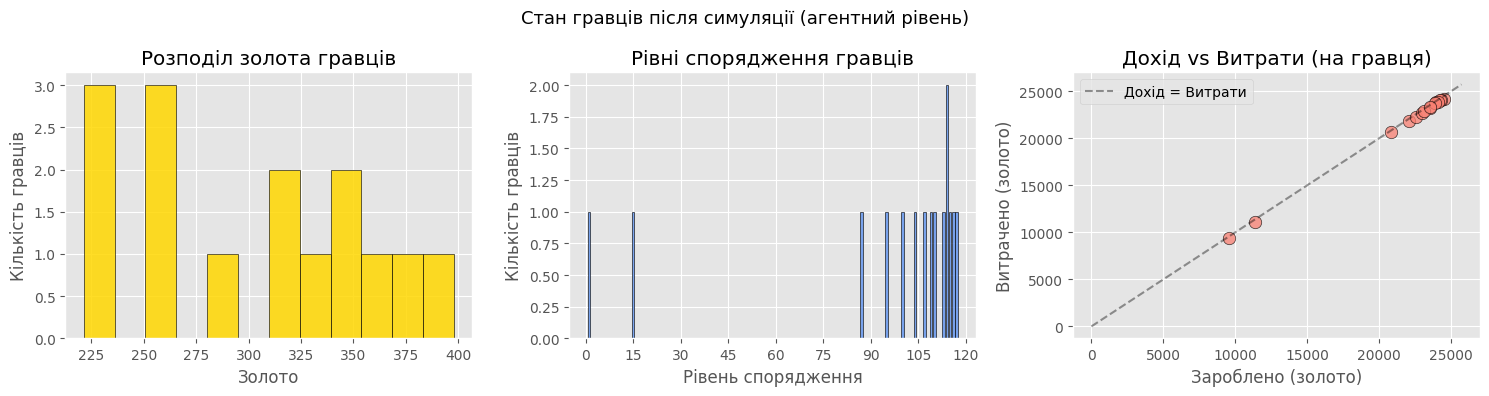

In [8]:
fig2, axes2 = plt.subplots(1, 3, figsize=(15, 4))
fig2.suptitle('Стан гравців після симуляції (агентний рівень)', fontsize=13)

gold_vals = [p.gold for p in sim.players]
axes2[0].hist(gold_vals, bins=12, color='gold', edgecolor='black', alpha=0.85)
axes2[0].set_title('Розподіл золота гравців')
axes2[0].set_xlabel('Золото');  axes2[0].set_ylabel('Кількість гравців')

eq_vals = [p.equipment_level for p in sim.players]
unique, counts = np.unique(eq_vals, return_counts=True)
axes2[1].bar(unique, counts, color='cornflowerblue', edgecolor='black', alpha=0.85)
axes2[1].set_title('Рівні спорядження гравців')
axes2[1].set_xlabel('Рівень спорядження');  axes2[1].set_ylabel('Кількість гравців')
axes2[1].xaxis.set_major_locator(plt.MaxNLocator(integer=True))

earned = [p.total_gold_earned for p in sim.players]
spent  = [p.total_gold_spent  for p in sim.players]
axes2[2].scatter(earned, spent, alpha=0.75, color='salmon', edgecolor='black', s=80)
mv = max(max(earned), max(spent)) * 1.05
axes2[2].plot([0, mv], [0, mv], 'k--', alpha=0.4, label='Дохід = Витрати')
axes2[2].set_title('Дохід vs Витрати (на гравця)')
axes2[2].set_xlabel('Зароблено (золото)');  axes2[2].set_ylabel('Витрачено (золото)')
axes2[2].legend()

plt.tight_layout()
plt.show()

## Висновки та обґрунтування оптимізації параметрів

### Маппінг на модель Лотка-Вольтерра

| ЛВ-змінна | MMO-аналог | Механізм |
|-----------|-----------|----------|
| **x(t)** — здобич | Популяція мобів | Розмножуються логістично, гинуть від гравців |
| **y(t)** — хижак | Дохід гравців за тік | Зростає від мобів, спадає через витрати |
| α — приріст здобичі | reproduction_rate = 0.50 | Логістичне відновлення мобів |
| β — тиск хижаків | alpha / y\* = 0.000739 | Скільки доходу «вилучає» один моб |
| δ — конверсія | gamma / x\* = 0.000187 | Скільки доходу генерує один моб |
| γ — спад хижаків | 0.0507 (gold_tax + daily_cost) | Природний відтік золота |

### Ключові зміни параметрів

1. **`DEFEAT_STRENGTH_PENALTY`: 90% → 2%**  
   При 90% одна поразка фактично видаляла гравця з симуляції → система колапсувала.  
   При 2% гравці залишаються активними → забезпечують стабільний тиск на мобів.

2. **`fights_per_tick`: 5 → 3, `n_players`: 30 → 15**  
   Загальна кількість вбивств за тік = n × f × win\_rate ≈ 30.  
   Темп розмноження при середній популяції 270: r × N × (1 − N/K) ≈ 0.5 × 270 × 0.23 ≈ 31.  
   Баланс забезпечує осциляції замість одностороннього знищення.

3. **`gold_tax = 1.5%/тік`**  
   Моделює аукціонні комісії та інфляцію. Забезпечує γ-подібний спад доходу,  
   коли кількість мобів мала → золото зменшується → цикл замикається.

4. **`EXP_CAP = 3.0`**  
   Без обмеження досвід зростає необмежено → сила гравців → ∞ → моби вимирають.  
   Обмеження підтримує рівновагу системи.

5. **`UPGRADE_THRESHOLD = 350`**  
   Гравці витрачають великі суми лише коли накопичать 350+ золота → природна затримка витрат.

### Результати калібрування

| Показник | Агентна модель | ЛВ рівновага |
|----------|---------------|-------------|
| Середня популяція мобів x\* | 270 | 272 |
| Середній дохід y\* | 674 зол./тік | 677 зол./тік |
| Період осциляцій | ~39 днів | ~39 днів |

### Переваги та обмеження

**Переваги** багаторівневого підходу:
- Гетерогенність гравців (різне спорядження, досвід, удача) дає більш реалістичну динаміку
- Стохастичність захоплює «ринковий шум», відсутній у детермінованій ЛВ
- Можна тестувати окремі механіки (ремонт, апгрейд) і бачити їх вплив на макроекономіку

**Обмеження**:
- Агентна фазова траєкторія — спіраль (збурення), а не замкнений еліпс класичної ЛВ
- Параметри потребують ручного калібрування під конкретну ігрову систему
- При дуже сильних збуреннях система може покинути область осциляцій
